In [6]:
import os
print(os.listdir('data/raw/'))

['99_q.csv', '79_c.csv', '56_c.wav', '292_c.csv', '13_c.wav', '141_c.wav', '104_c.wav', '6_b.csv', '335_a.csv', '90_e.wav', '28_e.wav', '42_e.csv', '64_f.csv', '193_c.csv', '21_f.csv', '240_c.wav', '205_c.wav', '8_m.csv', '84_c.csv', '64_q.csv', '1_n.wav', '110_e.csv', '21_q.csv', '72_b.wav', '37_b.wav', '18_b.csv', '11_a.wav', '290_a.csv', '54_a.wav', '106_a.wav', '129_a.csv', '143_a.wav', '372_c.csv', '337_c.csv', '318_c.wav', '40_g.csv', '30_n.csv', '23_d.csv', '191_a.csv', '66_d.csv', '49_d.wav', '134_d.csv', '228_a.csv', '86_a.csv', '207_a.wav', '171_d.csv', '242_a.wav', '17_g.wav', '22_n.wav', '38_g.csv', '2_q.csv', '74_d.wav', '183_a.wav', '31_d.wav', '163_d.wav', '250_a.csv', '94_a.wav', '2_f.csv', '126_d.wav', '215_a.csv', '109_d.csv', '25_b.csv', '60_b.csv', '408_c.wav', '46_a.csv', '69_a.wav', '19_h.wav', '282_a.wav', '151_a.csv', '114_a.csv', '5_j.wav', '89_d.wav', '325_c.wav', '360_c.wav', '0_s.csv', '50_e.wav', '15_e.wav', '33_f.wav', '181_c.wav', '59_f.csv', '76_f.wav', 

Sample rate: 44100 Hz
Duration: 2.00s


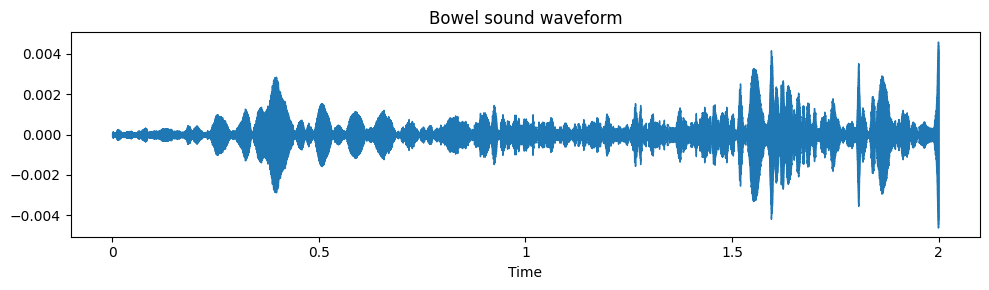

In [8]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

filepath = "data/raw/378_c.wav"

y, sr = librosa.load(filepath, sr=None)
print(f"Sample rate: {sr} Hz")
print(f"Duration: {len(y)/sr:.2f}s")

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Bowel sound waveform")
plt.tight_layout()
plt.show()

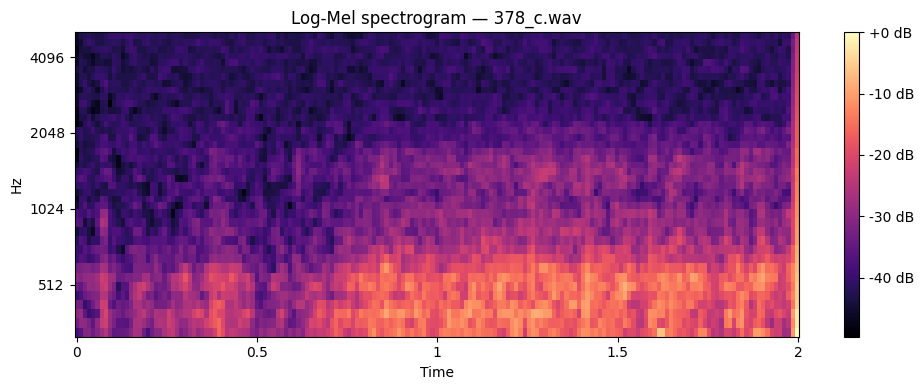

Spectrogram shape: (40, 173)


In [9]:
import numpy as np

# generate mel spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40, fmin=200, fmax=5000)
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', fmin=200, fmax=5000)
plt.colorbar(format='%+2.0f dB')
plt.title("Log-Mel spectrogram — 378_c.wav")
plt.tight_layout()
plt.show()

print(f"Spectrogram shape: {S_db.shape}")  # should be (40, something)

In [11]:
import pandas as pd

label_path = "data/raw/378_c.csv"
df = pd.read_csv(label_path)
print(df.head(20))
print(df.columns.tolist())

      start       end        fmin         fmax category
0  1.253515  1.270930  256.410278  1652.421631        s
1  1.401542  1.426213  256.410278   883.190857        s
2  1.604717  1.629388  119.658119   319.088318        s
3  1.789025  1.822404  102.564102   313.390320        s
4  1.984943  2.019773   91.168091   307.692322        s
['start', 'end', 'fmin', 'fmax', 'category']


In [12]:
import os

# to look at what label types exist across the whole dataset
categories = []
for fname in os.listdir("data/raw/"):
    if fname.endswith(".csv") and fname != "files.csv":
        try:
            df = pd.read_csv(f"data/raw/{fname}")
            if 'category' in df.columns:
                categories.extend(df['category'].dropna().tolist())
        except:
            pass

from collections import Counter
print(Counter(categories))

Counter({'s': 3439, 'bc': 103, 'b': 100, 'a': 34, 'm': 20, 'd': 2, 'o': 1})


In [13]:
import os
import pandas as pd
from collections import defaultdict

data = []

for fname in os.listdir("data/raw/"):
    if not fname.endswith(".wav"):
        continue
    
    wav_path = f"data/raw/{fname}"
    csv_path = wav_path.replace(".wav", ".csv")
    
    if not os.path.exists(csv_path):
        label = "silence"
    else:
        try:
            df = pd.read_csv(csv_path)
            has_event = df['category'].dropna().shape[0] > 0
            label = "sound" if has_event else "silence"
        except:
            label = "silence"
    
    data.append({"file": wav_path, "label": label})

df_dataset = pd.DataFrame(data)
print(df_dataset['label'].value_counts())
print(f"\nTotal clips: {len(df_dataset)}")

label
silence    1016
sound       590
Name: count, dtype: int64

Total clips: 1606


In [17]:
import numpy as np
import librosa
import os

os.makedirs("data/spectrograms", exist_ok=True)

failed = []

for i, row in df_dataset.iterrows():
    try:
        y, sr = librosa.load(row['file'], sr=None)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40, fmin=200, fmax=5000)
        S_db = librosa.power_to_db(S, ref=np.max)
        
        fname = os.path.basename(row['file']).replace(".wav", ".npy")
        np.save(f"data/spectrograms/{fname}", S_db)
    except Exception as e:
        failed.append((row['file'], str(e)))
    
    if i % 100 == 0:
        print(f"{i}/1606 done...")

print(f"Done. Saved {len(df_dataset) - len(failed)} spectrograms.")
print(f"Failed: {len(failed)}")

0/1606 done...
100/1606 done...
200/1606 done...
300/1606 done...
400/1606 done...
500/1606 done...
600/1606 done...
700/1606 done...
800/1606 done...
900/1606 done...
1000/1606 done...
1100/1606 done...
1200/1606 done...
1300/1606 done...
1400/1606 done...
1500/1606 done...
1600/1606 done...
Done. Saved 1606 spectrograms.
Failed: 0


In [18]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

# load all spectrograms and labels
X = []
y = []

for _, row in df_dataset.iterrows():
    fname = os.path.basename(row['file']).replace(".wav", ".npy")
    spec = np.load(f"data/spectrograms/{fname}")
    X.append(spec)
    y.append(1 if row['label'] == "sound" else 0)

X = np.array(X)
y = np.array(y)

# CNN expects shape (samples, height, width, channels)
X = X[..., np.newaxis]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}, sounds: {y.sum()}, silences: {(y==0).sum()}")

# split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

X shape: (1606, 40, 173, 1)
y shape: (1606,), sounds: 590, silences: 1016
Train: 1284, Test: 322


In [19]:
# build the CNN
model = keras.Sequential([
    keras.layers.Input(shape=(40, 173, 1)),
    
    keras.layers.Conv2D(16, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    
    keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    
    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 173, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 86, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 86, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 43, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 21, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6720)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       430,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 453,505 (1.73 MB)

 Trainable params: 453,505 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.5826 - loss: 1.8756 - val_accuracy: 0.6335 - val_loss: 0.6595
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.6301 - loss: 0.6641 - val_accuracy: 0.6335 - val_loss: 0.6655
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.6153 - loss: 0.6661 - val_accuracy: 0.6335 - val_loss: 0.6351
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.6488 - loss: 0.6379 - val_accuracy: 0.6366 - val_loss: 0.6353
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.6402 - loss: 0.6153 - val_accuracy: 0.6522 - val_loss: 0.5496
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.6846 - loss: 0.5596 - val_accuracy: 0.7143 - val_loss: 0.6116
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.7017 - loss: 0.5638 - val_accuracy: 0.7298 - val_loss: 0.5096
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7298 - loss: 0.4958 - val_accuracy: 0.7826 - v

Model saved.


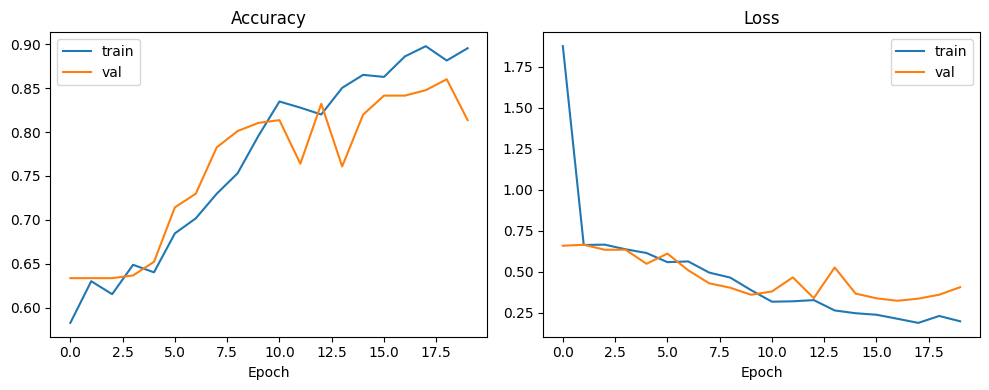

In [21]:
# save model
os.makedirs("models", exist_ok=True)
model.save("models/best_model.keras")
print("Model saved.")

# plot training curves
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
# predict on a new audio file
def predict_ir(filepath, model, threshold=0.5):
    y, sr = librosa.load(filepath, sr=None)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40, fmin=200, fmax=5000)
    S_db = librosa.power_to_db(S, ref=np.max)
    S_db = S_db[np.newaxis, ..., np.newaxis]  # add batch + channel dims
    
    prob = model.predict(S_db, verbose=0)[0][0]
    label = "sound" if prob > threshold else "silence"
    return {"file": filepath, "probability": round(float(prob), 3), "label": label}

# test on a few files
test_files = df_dataset.sample(5, random_state=1)['file'].tolist()

for f in test_files:
    result = predict_ir(f, model)
    actual = df_dataset[df_dataset['file'] == f]['label'].values[0]
    print(f"{os.path.basename(f):20s} → {result['label']:8s} (p={result['probability']}) | actual: {actual}")

115_b.wav            → sound    (p=0.604) | actual: silence
175_a.wav            → silence  (p=0.0) | actual: silence
30_d.wav             → silence  (p=0.0) | actual: silence
363_c.wav            → sound    (p=0.536) | actual: sound
0_j.wav              → sound    (p=0.654) | actual: sound


In [23]:
def compute_ir_score(audio_folder, model, n_files=30):
    """
    Simulate 1 minute of recording using 30 x 2s clips.
    Returns Intestinal Rate = detected sound events per minute.
    """
    wav_files = [f for f in os.listdir(audio_folder) if f.endswith(".wav")]
    sample = wav_files[:n_files]  # take first 30 = ~1 minute
    
    events = 0
    for fname in sample:
        result = predict_ir(f"{audio_folder}/{fname}", model)
        if result['label'] == "sound":
            events += 1
    
    ir = events  # events per minute
    print(f"Clips analysed: {n_files}")
    print(f"Sound events detected: {events}")
    print(f"Intestinal Rate (IR): {ir} events/min")
    print(f"Status: {'normal' if 5 <= ir <= 30 else 'abnormal'}")
    return ir

compute_ir_score("data/raw", model)

Clips analysed: 30
Sound events detected: 7
Intestinal Rate (IR): 7 events/min
Status: normal


7